<a href="https://colab.research.google.com/github/EmiiGit/Ciencia-de-datos/blob/main/EDA_Amazon_Ads_Optimizado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA — Amazon Ads Campaigns 2024-2025

> Análisis exploratorio completo para el armado del dashboard de Power BI.
> Autora: Junior BI Challenge | Última revisión: 2025

---

## Parte 1: Introducción y Carga de Datos

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Configuración global de gráficos ──────────────────────────
PALETTE = {"good": "#2ca02c", "warn": "#ff7f0e", "bad": "#d62728",
           "blue": "#1f77b4", "neutral": "#7f7f7f"}
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({"figure.figsize": (13, 5), "figure.dpi": 110,
                     "axes.spines.top": False, "axes.spines.right": False})

# ── Lectura de datos ──────────────────────────────────────────
FILE = "datos_BI_transformados.xlsx"

campaigns    = pd.read_excel(FILE, sheet_name="Campaigns_all")
dim_campaign = pd.read_excel(FILE, sheet_name="Campaigns_description")
placements   = pd.read_excel(FILE, sheet_name="Placement_all")

print(f"campaigns    : {campaigns.shape}")
print(f"dim_campaign : {dim_campaign.shape}")
print(f"placements   : {placements.shape}")
campaigns.head(3)

campaigns    : (265, 22)
dim_campaign : (134, 8)
placements   : (550, 5)


,campaign_id,campaign,region,country,language,objective,media_type,platform,date,budget,...,clicks,login,signups,add_to_cart,page_visits,begin_checkout,purchase,revenue,year,year_month
0,CAMP003,namer_us_english_conversion_programmatic_linke...,namer,us,english,conversion,programmatic,linkedin,"miércoles, 3 de enero de 2024",14800.0,...,50500,1180.0,390.0,290.0,44000,145.0,77.0,44000,2024,2024-01
1,CAMP005,apac_au_english_consideration_search_searchads...,apac,au,english,consideration,search,searchads,"jueves, 4 de enero de 2024",6800.0,...,21500,390.0,170.0,58.0,17500,28.0,14.0,12800,2024,2024-01
2,CAMP006,namer_us_english_conversion_social_snapchat_sa...,namer,us,english,conversion,social,snapchat,"jueves, 4 de enero de 2024",11800.0,...,39000,880.0,290.0,210.0,35500,115.0,62.0,27000,2024,2024-01


---
## Parte 2: Limpieza y Transformación

### 2.1 Nulos

In [3]:
# ── Nulos por tabla ───────────────────────────────────────────
for name, df in [("campaigns", campaigns), ("dim_campaign", dim_campaign), ("placements", placements)]:
    nulos = df.isnull().sum()
    nulos = nulos[nulos > 0]
    print(f"\n{'='*50}\nNULOS en {name.upper()}")
    print(nulos if len(nulos) else "  Sin nulos 🎉")


NULOS en CAMPAIGNS
budget            20
login             20
signups           10
add_to_cart       30
begin_checkout    10
purchase          10
dtype: int64

NULOS en DIM_CAMPAIGN
  Sin nulos 🎉

NULOS en PLACEMENTS
impressions    10
dtype: int64


### 2.2 Tipos de datos y columnas derivadas

In [4]:
# ── Fechas ────────────────────────────────────────────────────
campaigns["date"] = pd.to_datetime(campaigns["date"], errors="coerce")

# ── Columnas temporales ────────────────────────────────────────
if "year" not in campaigns.columns:
    campaigns["year"] = campaigns["date"].dt.year

if "year_month" not in campaigns.columns:
    campaigns["year_month"] = campaigns["date"].dt.to_period("M")

# ── Métricas base (sólo filas con spend > 0) ──────────────────
campaigns_valid = campaigns[campaigns["spend"] > 0].copy()
campaigns_valid["roas"] = campaigns_valid["revenue"] / campaigns_valid["spend"]
campaigns_valid["ctr"]  = campaigns_valid["clicks"]  / campaigns_valid["impressions"].replace(0, np.nan)
campaigns_valid["cpa"]  = campaigns_valid["spend"]   / campaigns_valid["purchase"].replace(0, np.nan)
campaigns_valid["cvr"]  = campaigns_valid["purchase"] / campaigns_valid["clicks"].replace(0, np.nan)
campaigns_valid["cpc"]  = campaigns_valid["spend"]   / campaigns_valid["clicks"].replace(0, np.nan)
campaigns_valid["cpm"]  = campaigns_valid["spend"]   / campaigns_valid["impressions"].replace(0, np.nan) * 1000

# Reflejar ROAS en tabla principal para compatibilidad
campaigns["roas"] = campaigns["revenue"] / campaigns["spend"].replace(0, np.nan)

print(f"Filas válidas (spend > 0) : {len(campaigns_valid)} / {len(campaigns)}")
print("\nNuevas columnas derivadas:", ["roas","ctr","cpa","cvr","cpc","cpm"])
campaigns_valid[["campaign_id","spend","revenue","roas","ctr","cpa","cvr"]].head(3)

Filas válidas (spend > 0) : 265 / 265

Nuevas columnas derivadas: ['roas', 'ctr', 'cpa', 'cvr', 'cpc', 'cpm']


,campaign_id,spend,revenue,roas,ctr,cpa,cvr
0,CAMP003,12500,44000,3.520000,0.025897,162.337662,0.001525
1,CAMP005,6600,12800,1.939394,0.025904,471.428571,0.000651
2,CAMP006,11300,27000,2.389381,0.041935,182.258065,0.001590


### 2.3 Detección de outliers

In [5]:
def detectar_outliers(df: pd.DataFrame, col: str):
    """Devuelve (df_outliers, lim_inf, lim_sup) usando método IQR."""
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    outliers = df[(df[col] < lim_inf) | (df[col] > lim_sup)]
    return outliers, lim_inf, lim_sup


METRICAS_OUTLIER = ["spend", "revenue", "impressions", "clicks", "purchase"]
outlier_ids: dict = {}

print(f"{'Métrica':<14} {'Lím. inf':>12} {'Lím. sup':>12} {'Outliers':>10}")
print("-" * 52)
for m in METRICAS_OUTLIER:
    df_m = campaigns_valid[campaigns_valid[m] > 0]
    out, li, ls = detectar_outliers(df_m, m)
    outlier_ids[m] = set(out["campaign_id"])
    print(f"{m:<14} {li:>12,.1f} {ls:>12,.1f} {len(out):>10}")

Métrica            Lím. inf     Lím. sup   Outliers
----------------------------------------------------
spend              -3,587.5     19,512.5          7
revenue           -37,800.0     64,920.0          8
impressions      -742,500.0  2,477,500.0          8
clicks            -29,500.0     75,300.0          8
purchase              -79.0        145.0         11


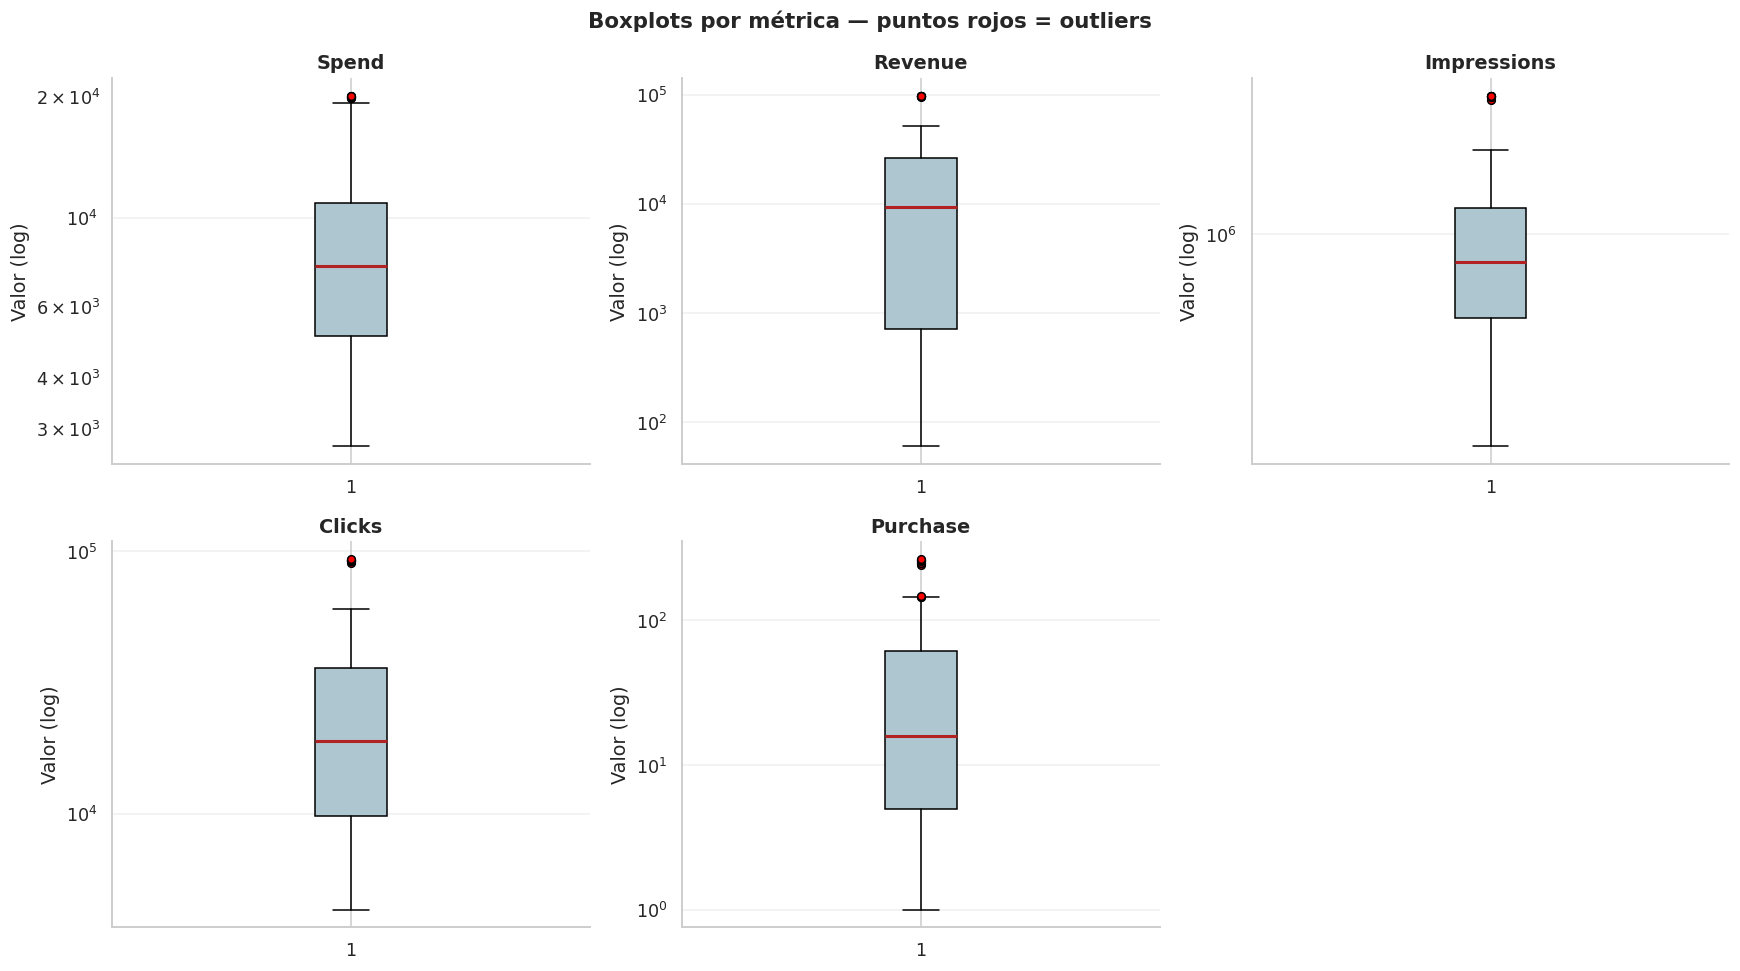

In [6]:
# ── Boxplots con outliers destacados ─────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for i, m in enumerate(METRICAS_OUTLIER):
    ax = axes[i // 3, i % 3]
    data = campaigns_valid[campaigns_valid[m] > 0][m]
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor="#AEC6CF"),
               medianprops=dict(color="firebrick", linewidth=2),
               flierprops=dict(marker="o", markerfacecolor="red", markersize=5))
    ax.set_yscale("log")
    ax.set_title(m.capitalize(), fontweight="bold")
    ax.set_ylabel("Valor (log)")
    ax.grid(axis="y", alpha=0.3)

axes[1, 2].axis("off")
fig.suptitle("Boxplots por métrica — puntos rojos = outliers", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

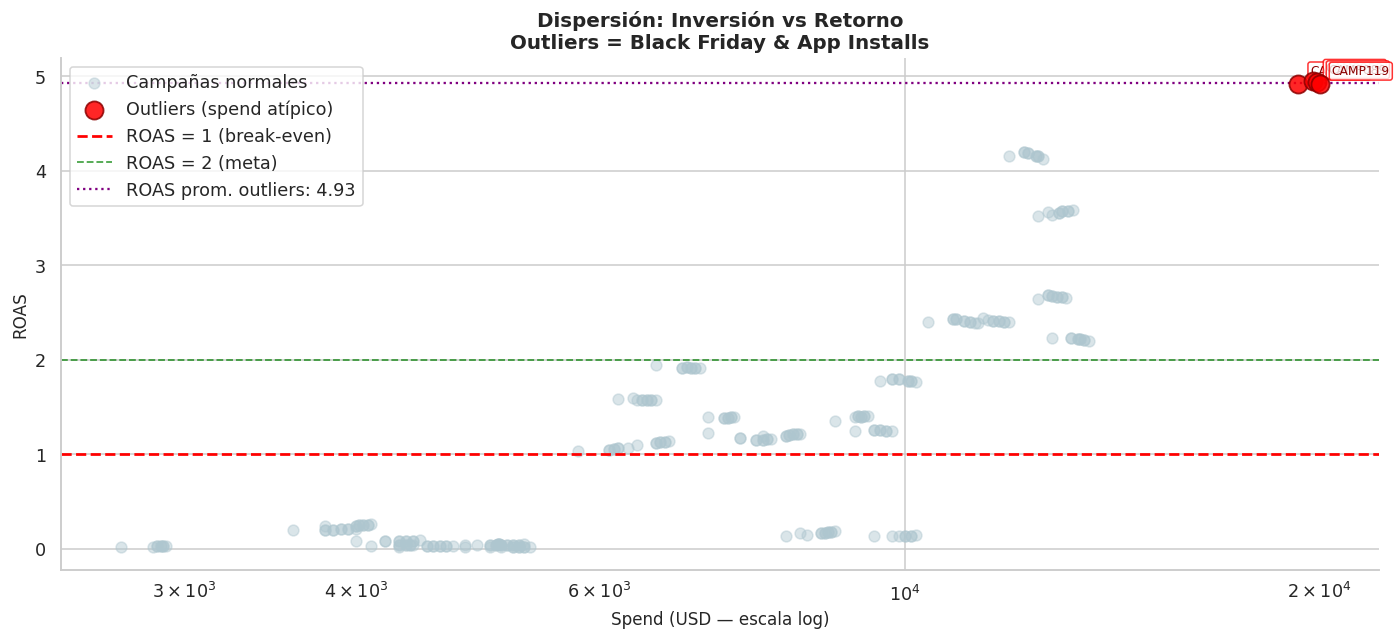

Outliers (4 campañas) → 3.6% del spend, 9.7% del revenue
ROAS outliers: 4.93 vs ROAS global: 1.84


In [7]:
# ── Scatter Spend vs ROAS con outliers etiquetados ───────────
out_spend, _, _ = detectar_outliers(campaigns_valid[campaigns_valid["spend"] > 0], "spend")
out_ids = set(out_spend["campaign_id"])

normal   = campaigns_valid[~campaigns_valid["campaign_id"].isin(out_ids)]
outliers = campaigns_valid[campaigns_valid["campaign_id"].isin(out_ids)].drop_duplicates("campaign_id")

fig, ax = plt.subplots(figsize=(13, 6))
ax.scatter(normal["spend"],   normal["roas"],   alpha=0.45, s=50,
           color="#AEC6CF", label="Campañas normales")
ax.scatter(outliers["spend"], outliers["roas"], alpha=0.85, s=140,
           color="red", edgecolors="darkred", linewidth=1.2, zorder=5,
           label="Outliers (spend atípico)")

for _, row in outliers.iterrows():
    ax.annotate(row["campaign_id"], (row["spend"], row["roas"]),
                xytext=(8, 6), textcoords="offset points",
                fontsize=8, color="darkred",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="red", alpha=0.8))

roas_out = outliers["revenue"].sum() / outliers["spend"].sum()
ax.axhline(1, color="red",    ls="--", lw=1.8, label="ROAS = 1 (break-even)")
ax.axhline(2, color="green",  ls="--", lw=1.2, alpha=0.7, label="ROAS = 2 (meta)")
ax.axhline(roas_out, color="purple", ls=":", lw=1.5,
           label=f"ROAS prom. outliers: {roas_out:.2f}")
ax.set_xscale("log")
ax.set_xlabel("Spend (USD — escala log)", fontsize=11)
ax.set_ylabel("ROAS", fontsize=11)
ax.set_title("Dispersión: Inversión vs Retorno\nOutliers = Black Friday & App Installs", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

# Contexto de impacto
s_out  = outliers["spend"].sum()
r_out  = outliers["revenue"].sum()
s_tot  = campaigns_valid["spend"].sum()
r_tot  = campaigns_valid["revenue"].sum()
print(f"Outliers ({len(outliers)} campañas) → {s_out/s_tot*100:.1f}% del spend, {r_out/r_tot*100:.1f}% del revenue")
print(f"ROAS outliers: {roas_out:.2f} vs ROAS global: {r_tot/s_tot:.2f}")

> **Hallazgo:** Los outliers corresponden a campañas de **Black Friday** y **App Installs**. No son errores — son el benchmark de máximo rendimiento y deben conservarse en el análisis.

---
## Parte 3: Análisis Exploratorio y Métricas Clave

### 3.1 Estadísticas descriptivas

In [8]:
METRICAS_DESC = ["spend", "revenue", "impressions", "clicks", "purchase"]
campaigns_valid[METRICAS_DESC].describe().round(2)

,spend,revenue,impressions,clicks,purchase
count,265.00,265.00,265.00,265.00,255.00
mean,8204.98,15120.89,937135.85,24435.47,35.73
std,3718.57,20518.21,684623.08,18705.49,52.00
min,2700.00,60.00,145000.00,4300.00,1.00
25%,5075.00,720.00,465000.00,9800.00,5.00
50%,7600.00,9400.00,780000.00,19000.00,16.00
75%,10850.00,26400.00,1270000.00,36000.00,61.00
max,20100.00,98600.00,3530000.00,93500.00,265.00


### 3.2 KPIs globales por año

In [9]:
kpis = (
    campaigns_valid
    .groupby("year")
    .agg(spend=("spend","sum"), revenue=("revenue","sum"),
         clicks=("clicks","sum"), impressions=("impressions","sum"),
         purchase=("purchase","sum"), budget=("budget","sum"))
    .assign(
        roas   = lambda d: d.revenue / d.spend,
        ctr    = lambda d: d.clicks  / d.impressions * 100,
        cpa    = lambda d: d.spend   / d.purchase,
        budget_util = lambda d: d.spend / d.budget * 100
    )
)

cols_show = ["spend", "revenue", "roas", "ctr", "cpa", "budget_util"]
kpis[cols_show].style.format({
    "spend": "${:,.0f}", "revenue": "${:,.0f}",
    "roas": "{:.2f}×", "ctr": "{:.2f}%",
    "cpa": "${:.0f}", "budget_util": "{:.1f}%"
})

,spend,revenue,roas,ctr,cpa,budget_util
year,,,,,,
2024,"$1,088,120","$1,997,650",1.84×,2.61%,$243,98.9%
2025,"$1,086,200","$2,009,385",1.85×,2.61%,$235,98.8%


### 3.3 Evolución mensual (Spend, Revenue, ROAS)

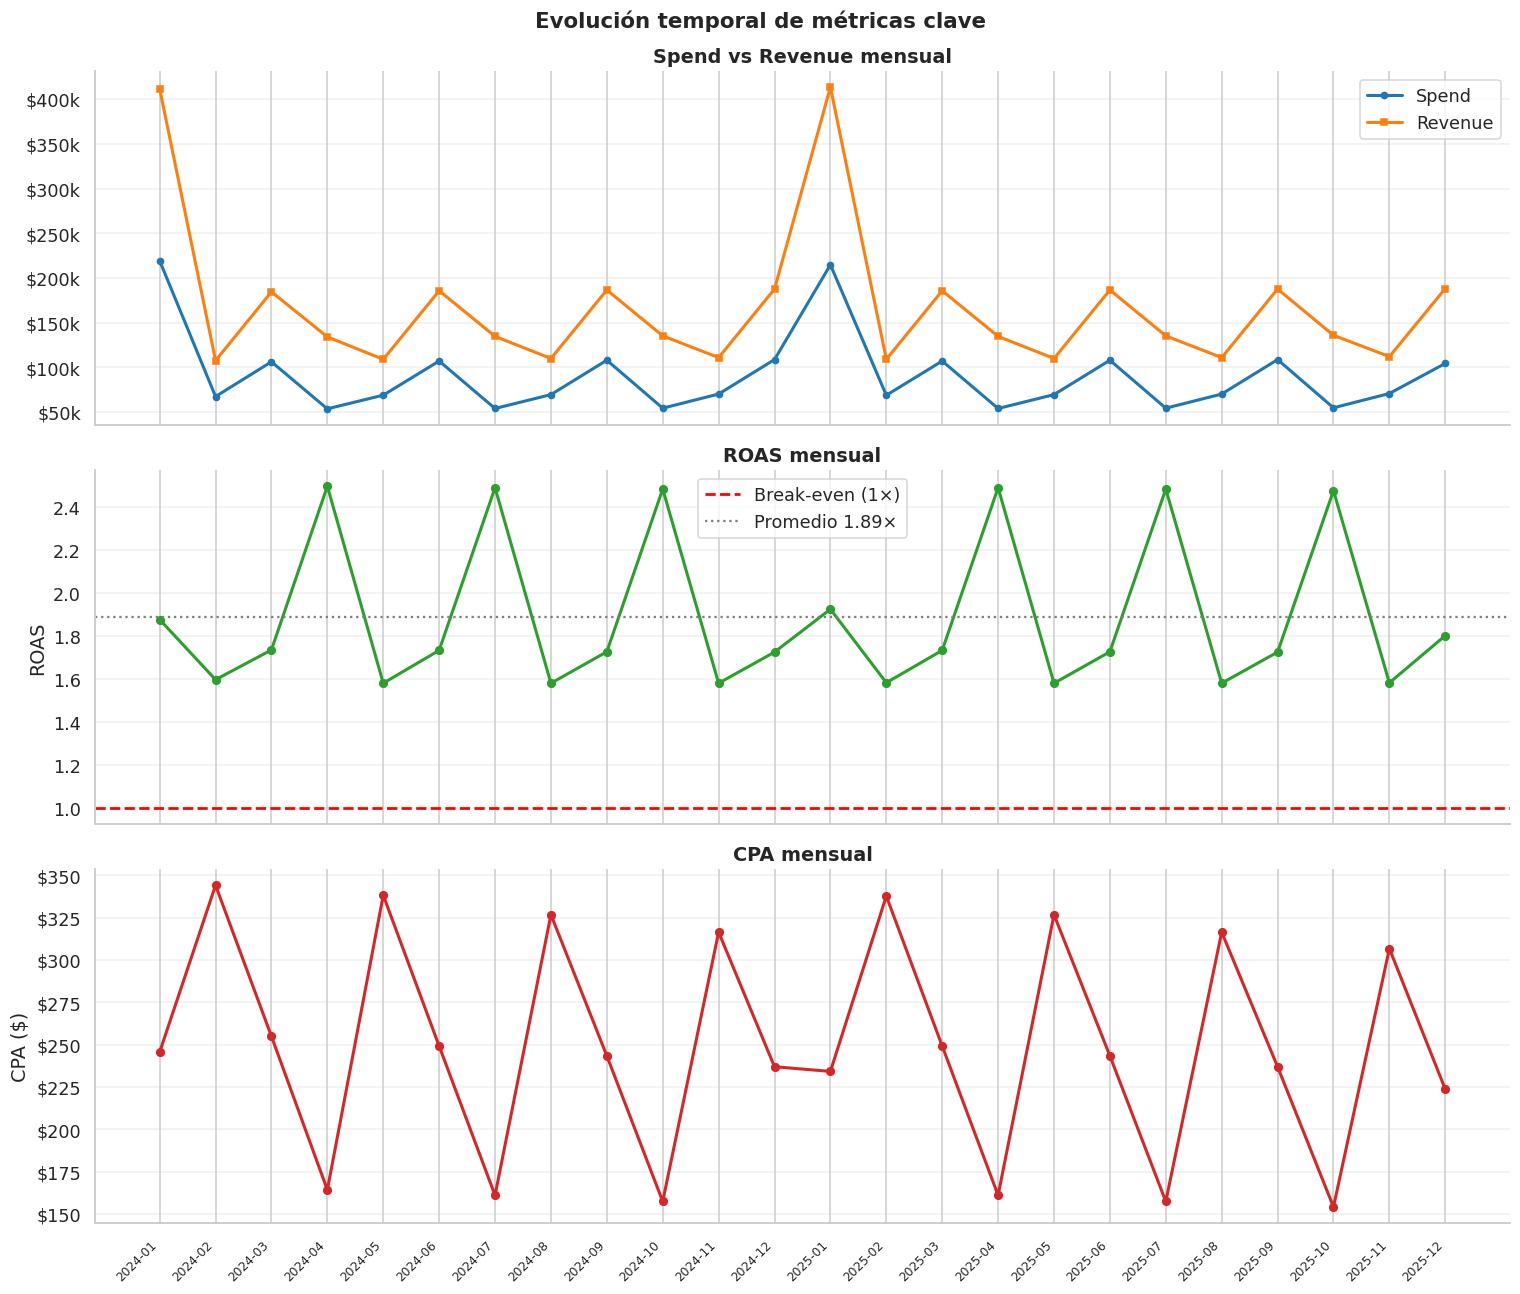

In [10]:
evolucion = (
    campaigns_valid
    .groupby("year_month")
    .agg(spend=("spend","sum"), revenue=("revenue","sum"),
         clicks=("clicks","sum"), impressions=("impressions","sum"),
         purchase=("purchase","sum"))
    .assign(
        roas = lambda d: d.revenue / d.spend,
        ctr  = lambda d: d.clicks  / d.impressions * 100,
        cpa  = lambda d: d.spend   / d.purchase
    )
    .reset_index()
)
evolucion["ym_str"] = evolucion["year_month"].astype(str)

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Spend vs Revenue
axes[0].plot(evolucion["ym_str"], evolucion["spend"],   marker="o", ms=4, lw=2, color="#1f77b4", label="Spend")
axes[0].plot(evolucion["ym_str"], evolucion["revenue"], marker="s", ms=4, lw=2, color="#ff7f0e", label="Revenue")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}k"))
axes[0].set_title("Spend vs Revenue mensual", fontweight="bold")
axes[0].legend()

# ROAS
axes[1].plot(evolucion["ym_str"], evolucion["roas"], marker="o", ms=5, lw=2, color="#2ca02c")
axes[1].axhline(1, color="red",   ls="--", lw=1.8, label="Break-even (1×)")
axes[1].axhline(evolucion["roas"].mean(), color="gray", ls=":", lw=1.5,
               label=f"Promedio {evolucion['roas'].mean():.2f}×")
axes[1].set_ylabel("ROAS")
axes[1].set_title("ROAS mensual", fontweight="bold")
axes[1].legend()

# CPA
axes[2].plot(evolucion["ym_str"], evolucion["cpa"], marker="o", ms=5, lw=2, color="#d62728")
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}"))
axes[2].set_ylabel("CPA ($)")
axes[2].set_title("CPA mensual", fontweight="bold")

for ax in axes:
    ax.grid(axis="y", alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)

fig.suptitle("Evolución temporal de métricas clave", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 3.4 ROAS por campaña — ranking y break-even

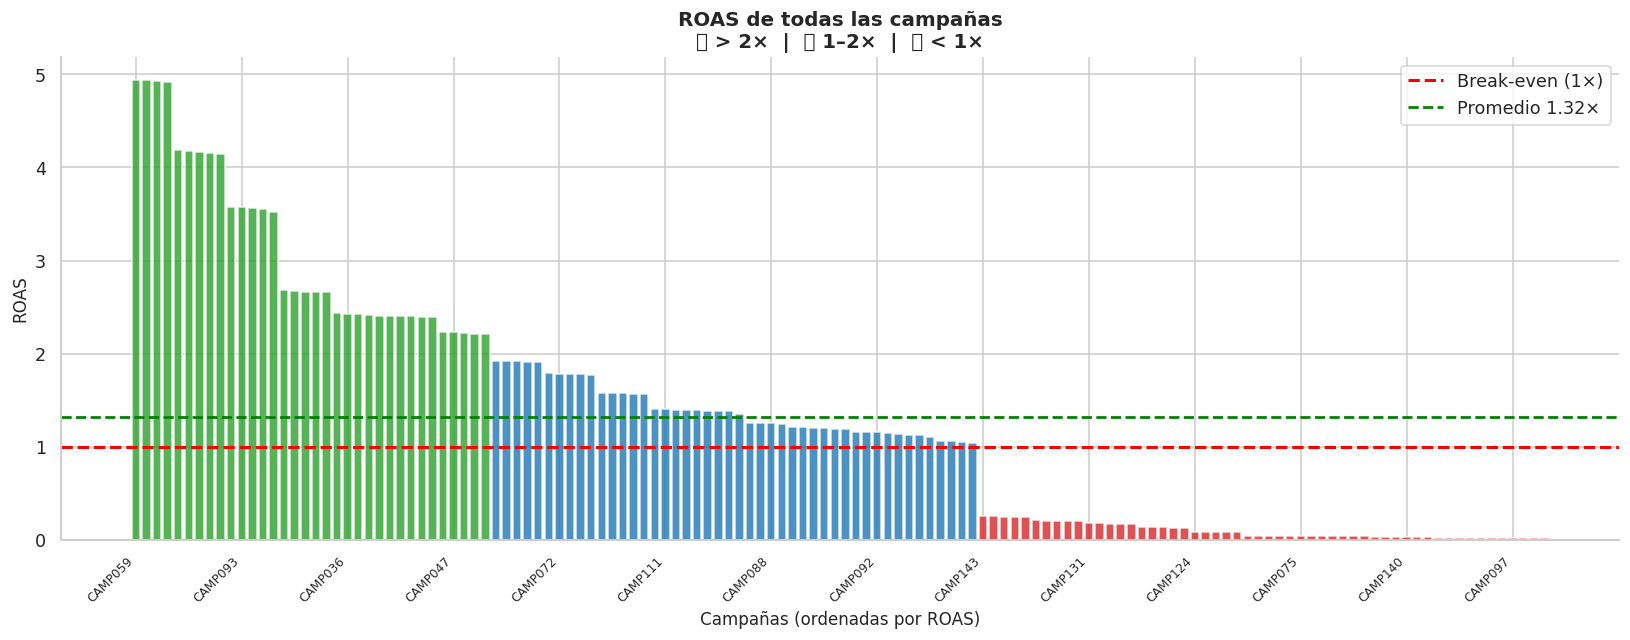

Campañas con ROAS < 1  : 54 (40.3%)  | Pérdida neta: $501,775
Campañas con ROAS > 2  : 34  (25.4%)  | Revenue generado: $2,940,840


In [11]:
todas_camp = (
    campaigns_valid
    .groupby("campaign_id")
    .agg(spend=("spend","sum"), revenue=("revenue","sum"))
    .assign(roas=lambda d: d.revenue / d.spend)
    .sort_values("roas", ascending=False)
    .reset_index()
)
todas_camp["pos"] = range(1, len(todas_camp) + 1)

roas_prom = todas_camp["roas"].mean()
perdidas  = todas_camp[todas_camp["roas"] < 1]
buenas    = todas_camp[todas_camp["roas"] > 2]

fig, ax = plt.subplots(figsize=(15, 6))
colors = todas_camp["roas"].apply(
    lambda r: "#2ca02c" if r > 2 else ("#d62728" if r < 1 else "#1f77b4")
)
ax.bar(todas_camp["pos"], todas_camp["roas"], color=colors, width=0.8, alpha=0.8)
ax.axhline(1,         color="red",   ls="--", lw=2,   label="Break-even (1×)")
ax.axhline(roas_prom, color="green", ls="--", lw=1.8, label=f"Promedio {roas_prom:.2f}×")
ax.set_xlabel("Campañas (ordenadas por ROAS)", fontsize=11)
ax.set_ylabel("ROAS", fontsize=11)
ax.set_title("ROAS de todas las campañas\n🟢 > 2×  |  🔵 1–2×  |  🔴 < 1×", fontsize=13, fontweight="bold")
ax.set_xticks(todas_camp["pos"][::10])
ax.set_xticklabels(todas_camp["campaign_id"].iloc[::10], rotation=45, ha="right", fontsize=8)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Campañas con ROAS < 1  : {len(perdidas)} ({len(perdidas)/len(todas_camp)*100:.1f}%)  | "
      f"Pérdida neta: ${perdidas['spend'].sum() - perdidas['revenue'].sum():,.0f}")
print(f"Campañas con ROAS > 2  : {len(buenas)}  ({len(buenas)/len(todas_camp)*100:.1f}%)  | "
      f"Revenue generado: ${buenas['revenue'].sum():,.0f}")

### 3.5 Análisis de concentración — curva de Pareto

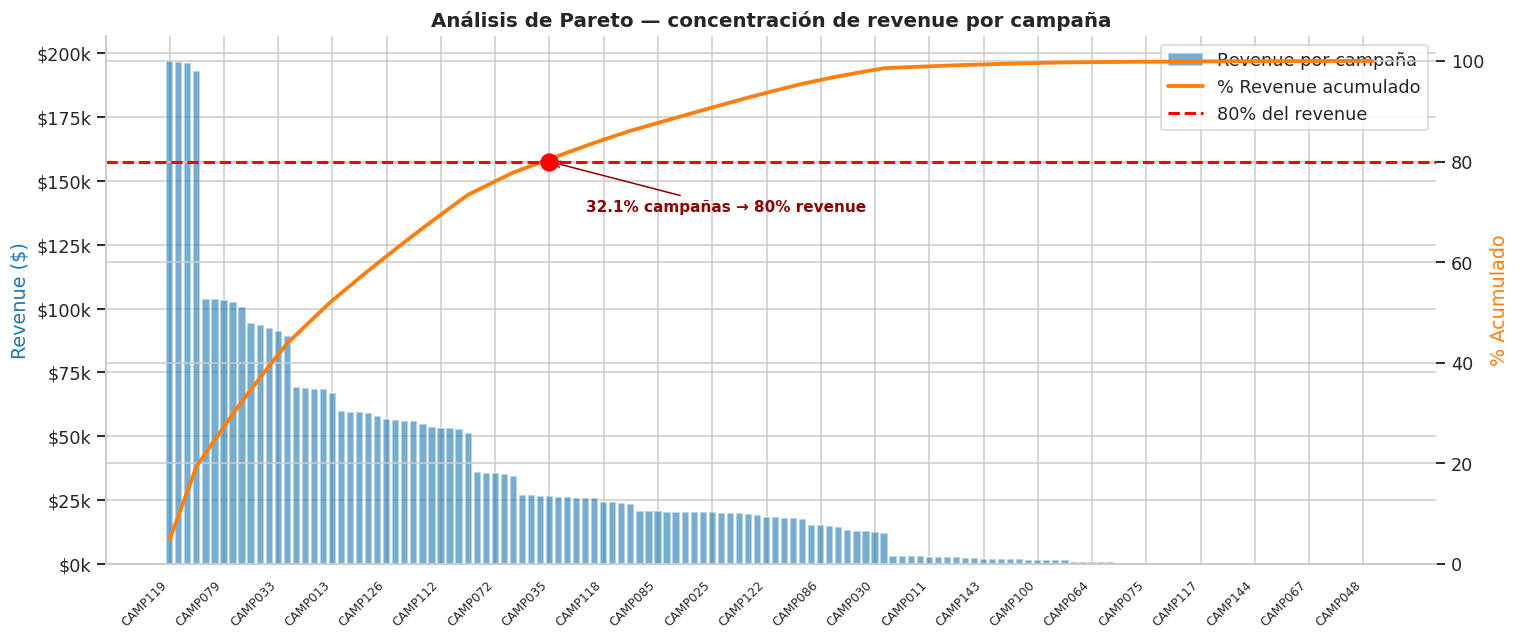

Regla 80/20: el 32.1% de las campañas (43 de 134) generan el 80% del revenue.


In [12]:
rev_camp = todas_camp.sort_values("revenue", ascending=False).copy()
rev_camp["rev_pct"] = rev_camp["revenue"] / rev_camp["revenue"].sum() * 100
rev_camp["cum_pct"] = rev_camp["rev_pct"].cumsum()

n80  = (rev_camp["cum_pct"] <= 80).sum() + 1
pct80 = n80 / len(rev_camp) * 100

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

x = np.arange(len(rev_camp))
ax1.bar(x, rev_camp["revenue"], color="#1f77b4", alpha=0.6, label="Revenue por campaña")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1e3:.0f}k"))
ax1.set_ylabel("Revenue ($)", color="#1f77b4")

ax2.plot(x, rev_camp["cum_pct"], color="#ff7f0e", lw=2.5, label="% Revenue acumulado")
ax2.axhline(80, color="red", ls="--", lw=2, label="80% del revenue")
ax2.set_ylabel("% Acumulado", color="#ff7f0e")
ax2.set_ylim(0, 105)

ax2.scatter(n80 - 1, 80, color="red", s=120, zorder=6)
ax2.annotate(f"{pct80:.1f}% campañas → 80% revenue",
             xy=(n80 - 1, 80), xytext=(n80 + 3, 70),
             arrowprops=dict(arrowstyle="->", color="darkred"),
             fontsize=10, fontweight="bold", color="darkred")

ax1.set_xticks(x[::max(1, len(x)//20)])
ax1.set_xticklabels(rev_camp["campaign_id"].iloc[::max(1, len(x)//20)], rotation=45, ha="right", fontsize=8)
ax1.set_title("Análisis de Pareto — concentración de revenue por campaña", fontsize=13, fontweight="bold")

lines = (ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0])
labels = (ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1])
ax1.legend(lines, labels, loc="upper right")

plt.tight_layout()
plt.show()
print(f"Regla 80/20: el {pct80:.1f}% de las campañas ({n80} de {len(rev_camp)}) generan el 80% del revenue.")

### 3.6 Funnel de conversión

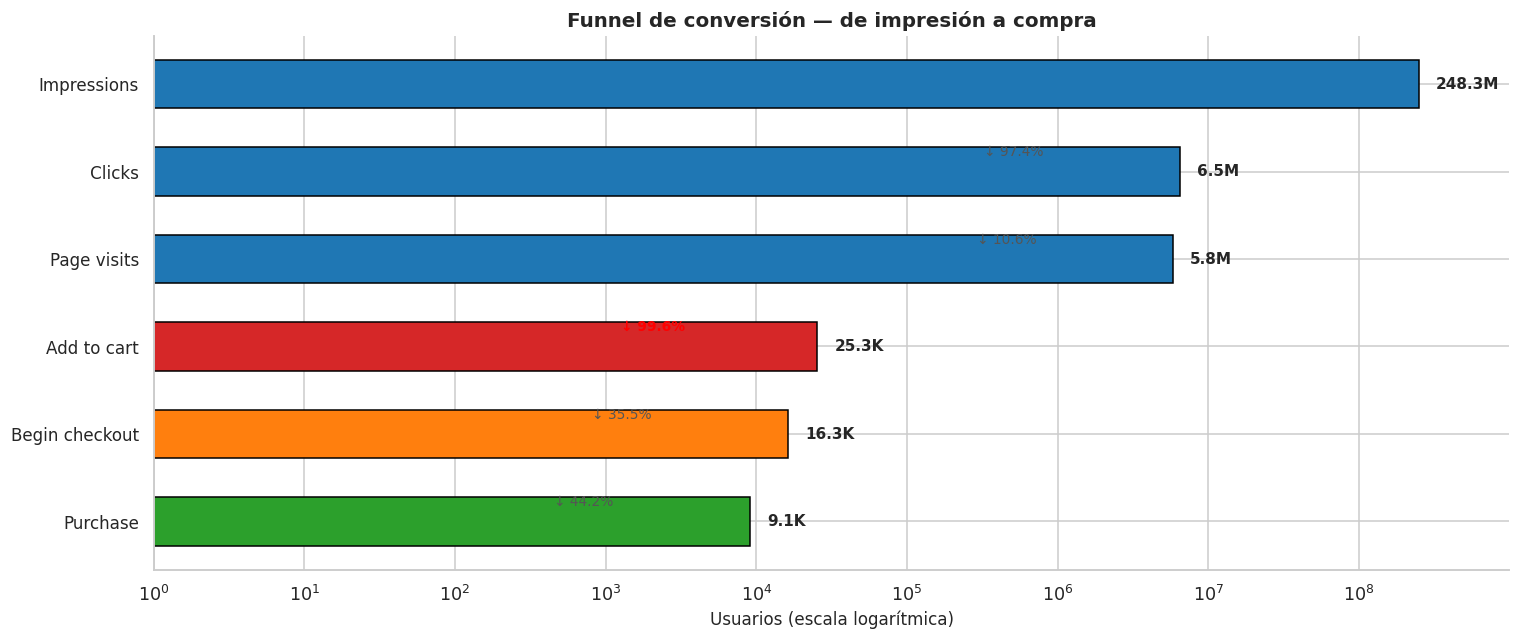

     Impressions → Clicks          : ↓ 97.4%
          Clicks → Page visits     : ↓ 10.6%
     Page visits → Add to cart     : ↓ 99.6% 🔴 CRÍTICO
     Add to cart → Begin checkout  : ↓ 35.5%
  Begin checkout → Purchase        : ↓ 44.2%


In [13]:
ETAPAS   = ["Impressions", "Clicks", "Page visits", "Add to cart", "Begin checkout", "Purchase"]
VALORES  = [
    campaigns["impressions"].sum(),
    campaigns["clicks"].sum(),
    campaigns.get("page_visits", pd.Series([0])).sum() or campaigns["clicks"].sum() * 0.91,
    campaigns["add_to_cart"].sum(),
    campaigns["begin_checkout"].sum(),
    campaigns["purchase"].sum()
]

drops = [None] + [
    (VALORES[i-1] - VALORES[i]) / VALORES[i-1] * 100
    for i in range(1, len(VALORES))
]
COLORES = ["#1f77b4"] * 3 + ["#d62728", "#ff7f0e", "#2ca02c"]

fig, ax = plt.subplots(figsize=(14, 6))
y = np.arange(len(ETAPAS))
bars = ax.barh(y, VALORES, color=COLORES, edgecolor="black", height=0.55)
ax.set_yticks(y)
ax.set_yticklabels(ETAPAS, fontsize=11)
ax.set_xscale("log")
ax.invert_yaxis()
ax.set_xlabel("Usuarios (escala logarítmica)", fontsize=11)
ax.set_title("Funnel de conversión — de impresión a compra", fontsize=13, fontweight="bold")

for i, (bar, val, drop) in enumerate(zip(bars, VALORES, drops)):
    fmt = f"{val/1e6:.1f}M" if val >= 1e6 else (f"{val/1e3:.1f}K" if val >= 1e3 else f"{val:,.0f}")
    ax.text(bar.get_width() * 1.3, bar.get_y() + bar.get_height() / 2,
            fmt, va="center", fontsize=10, fontweight="bold")
    if drop is not None:
        color = "red" if i == 3 else "#555"
        fw = "bold" if i == 3 else "normal"
        ax.text(bar.get_width() * 0.05, bar.get_y() - 0.03,
                f"↓ {drop:.1f}%", va="top", fontsize=9, color=color, fontweight=fw)

ax.set_xlim(1, max(VALORES) * 4)
plt.tight_layout()
plt.show()

for i in range(1, len(ETAPAS)):
    critico = " 🔴 CRÍTICO" if i == 3 else ""
    print(f"{ETAPAS[i-1]:>16} → {ETAPAS[i]:<16}: ↓ {drops[i]:.1f}%{critico}")

---
## Parte 4: Análisis Multidimensional

### 4.1 ROAS por región, objetivo y canal

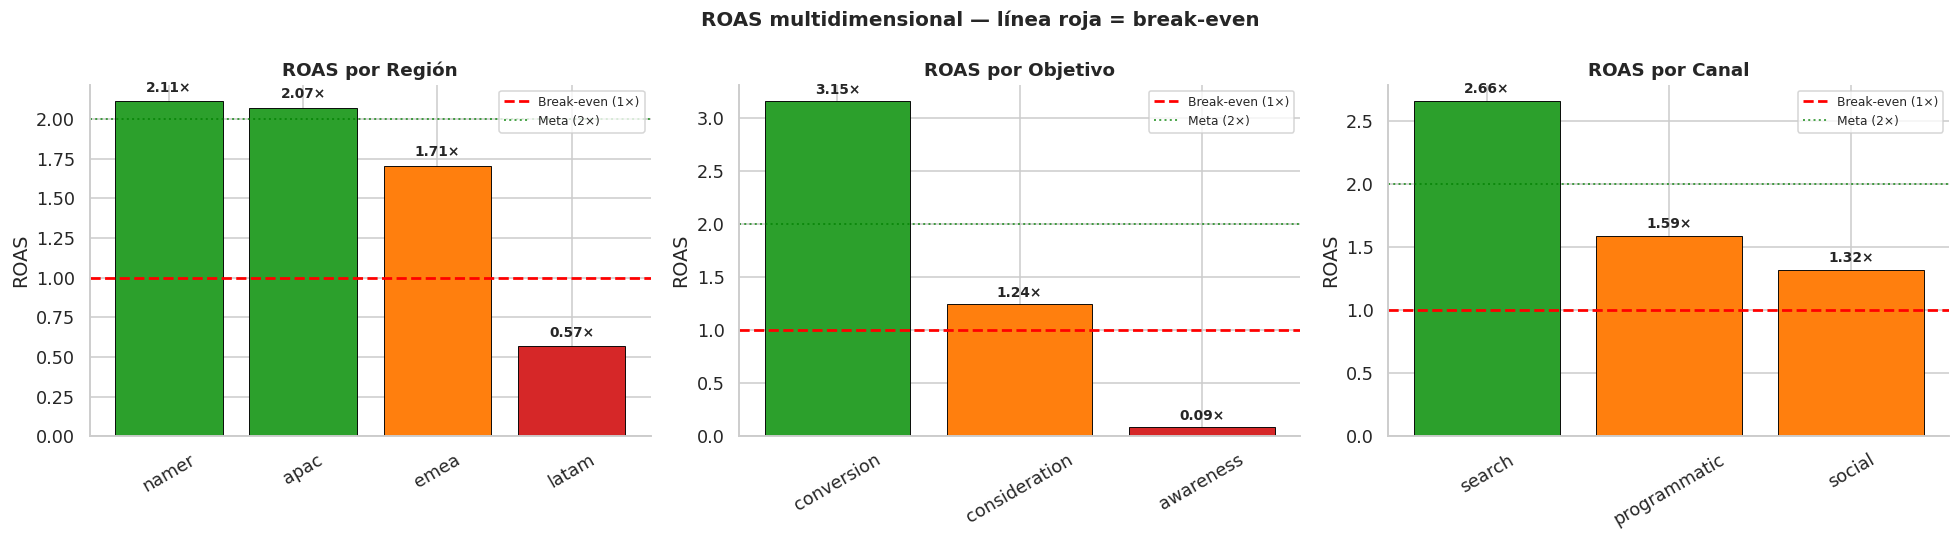

In [14]:
def roas_por(df, col):
    return (
        df.groupby(col)
        .apply(lambda x: x["revenue"].sum() / x["spend"].sum())
        .rename("roas")
        .sort_values(ascending=False)
        .reset_index()
    )

roas_reg  = roas_por(campaigns_valid, "region")
roas_obj  = roas_por(campaigns_valid, "objective")
roas_chan  = roas_por(campaigns_valid, "media_type")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
palettes = [
    ["#2ca02c" if v > 2 else ("#ff7f0e" if v >= 1 else "#d62728") for v in roas_reg["roas"]],
    ["#2ca02c" if v > 2 else ("#ff7f0e" if v >= 1 else "#d62728") for v in roas_obj["roas"]],
    ["#2ca02c" if v > 2 else ("#ff7f0e" if v >= 1 else "#d62728") for v in roas_chan["roas"]],
]
titles = ["ROAS por Región", "ROAS por Objetivo", "ROAS por Canal"]
dfs    = [roas_reg, roas_obj, roas_chan]
xcols  = ["region", "objective", "media_type"]

for ax, df, xcol, title, pal in zip(axes, dfs, xcols, titles, palettes):
    bars = ax.bar(df[xcol], df["roas"], color=pal, edgecolor="black", linewidth=0.6)
    ax.axhline(1, color="red", ls="--", lw=1.8, label="Break-even (1×)")
    ax.axhline(2, color="green", ls=":", lw=1.3, alpha=0.7, label="Meta (2×)")
    for bar, val in zip(bars, df["roas"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.04,
                f"{val:.2f}×", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel("ROAS")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(fontsize=8)

plt.suptitle("ROAS multidimensional — línea roja = break-even", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 4.2 Heatmap ROAS región × canal

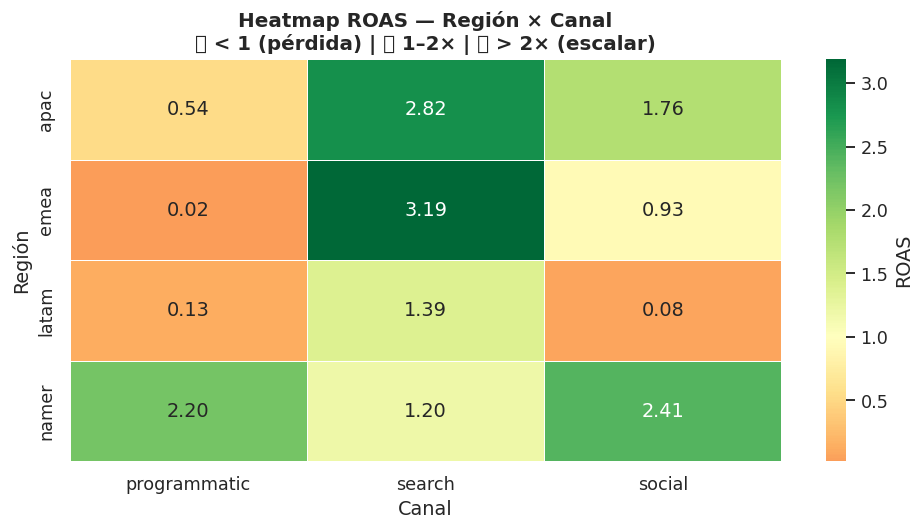

In [15]:
matriz_roas = (
    campaigns_valid
    .groupby(["region", "media_type"])
    .apply(lambda x: x["revenue"].sum() / x["spend"].sum())
    .unstack(fill_value=0)
    .round(2)
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(matriz_roas, annot=True, fmt=".2f", cmap="RdYlGn", center=1,
            linewidths=0.6, cbar_kws={"label": "ROAS"}, ax=ax)
ax.set_title("Heatmap ROAS — Región × Canal\n🔴 < 1 (pérdida) | 🟡 1–2× | 🟢 > 2× (escalar)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Canal")
ax.set_ylabel("Región")
plt.tight_layout()
plt.show()

### 4.3 Heatmap ROAS canal × objetivo

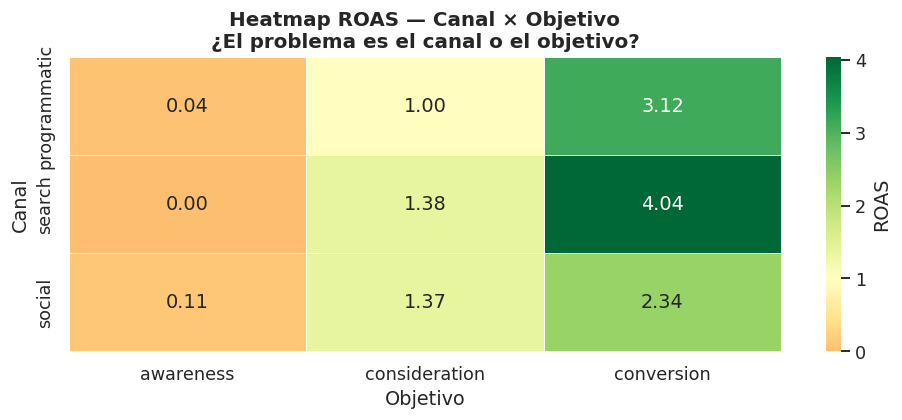

In [16]:
matriz_canal_obj = (
    campaigns_valid
    .groupby(["media_type", "objective"])
    .apply(lambda x: x["revenue"].sum() / x["spend"].sum())
    .unstack(fill_value=0)
    .round(2)
)

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(matriz_canal_obj, annot=True, fmt=".2f", cmap="RdYlGn", center=1,
            linewidths=0.6, cbar_kws={"label": "ROAS"}, ax=ax)
ax.set_title("Heatmap ROAS — Canal × Objetivo\n¿El problema es el canal o el objetivo?",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Objetivo")
ax.set_ylabel("Canal")
plt.tight_layout()
plt.show()

### 4.4 Spend vs Revenue por región, objetivo y canal

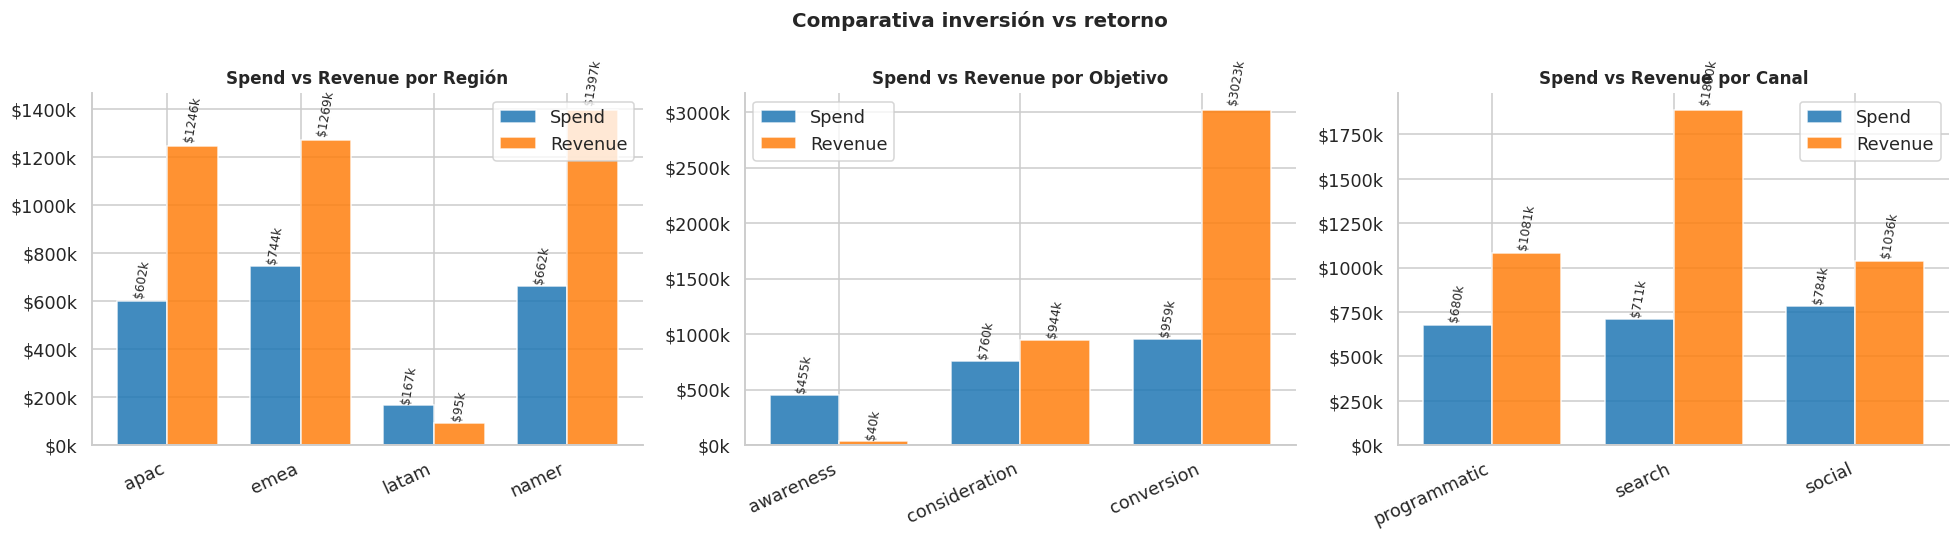

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
dims = [("region", "Región"), ("objective", "Objetivo"), ("media_type", "Canal")]

for ax, (col, label) in zip(axes, dims):
    df = campaigns_valid.groupby(col)[["spend", "revenue"]].sum().reset_index()
    x = np.arange(len(df))
    w = 0.38
    b1 = ax.bar(x - w/2, df["spend"],   w, label="Spend",   color="#1f77b4", alpha=0.85)
    b2 = ax.bar(x + w/2, df["revenue"], w, label="Revenue", color="#ff7f0e", alpha=0.85)
    for bar in [*b1, *b2]:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h * 1.01,
                f"${h/1e3:.0f}k", ha="center", va="bottom", fontsize=8, rotation=80)
    ax.set_xticks(x)
    ax.set_xticklabels(df[col], rotation=25, ha="right")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1e3:.0f}k"))
    ax.set_title(f"Spend vs Revenue por {label}", fontsize=11, fontweight="bold")
    ax.legend()

plt.suptitle("Comparativa inversión vs retorno", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 4.5 CPA multidimensional

✅ Mejor combinación  → emea | conversion | search | CPA: $78
❌ Peor  combinación  → apac  | awareness  | social  | CPA: $1,818
   Diferencia: 23× más costoso


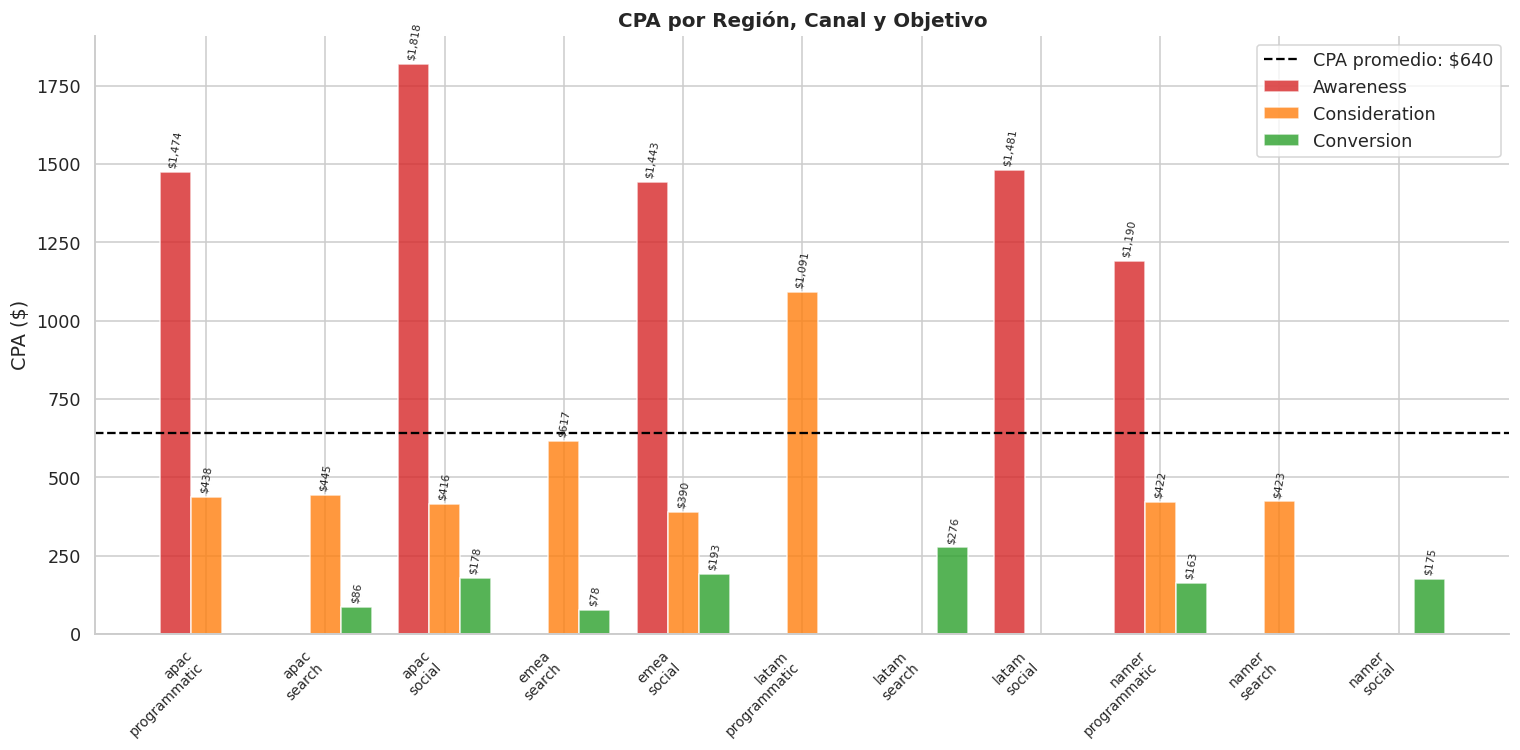

In [18]:
cpa_dim = (
    campaigns_valid
    .groupby(["region", "objective", "media_type"])
    .agg(spend=("spend","sum"), purchase=("purchase","sum"))
    .query("purchase > 0")
    .assign(cpa=lambda d: d.spend / d.purchase)
    .reset_index()
    .sort_values("cpa")
)

mejor = cpa_dim.iloc[0]
peor  = cpa_dim.iloc[-1]
print(f"✅ Mejor combinación  → {mejor.region} | {mejor.objective} | {mejor.media_type} | CPA: ${mejor.cpa:,.0f}")
print(f"❌ Peor  combinación  → {peor.region}  | {peor.objective}  | {peor.media_type}  | CPA: ${peor.cpa:,.0f}")
print(f"   Diferencia: {peor.cpa/mejor.cpa:.0f}× más costoso")

# Pivot para gráfico
pivot_cpa = cpa_dim.pivot_table(
    index=["region", "media_type"], columns="objective", values="cpa"
).fillna(0)

fig, ax = plt.subplots(figsize=(14, 7))
x   = np.arange(len(pivot_cpa))
w   = 0.26
ofs = [-1, 0, 1]
cols_obj = list(pivot_cpa.columns)
colors_obj = ["#d62728", "#ff7f0e", "#2ca02c"]

for offset, obj, col in zip(ofs, cols_obj, colors_obj):
    vals = pivot_cpa.get(obj, pd.Series([0]*len(pivot_cpa))).values
    bars = ax.bar(x + offset*w, vals, w, label=obj.capitalize(), color=col, alpha=0.8)
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 10,
                    f"${h:,.0f}", ha="center", va="bottom", fontsize=7, rotation=80)

ax.axhline(cpa_dim["cpa"].mean(), color="black", ls="--", lw=1.5,
           label=f"CPA promedio: ${cpa_dim['cpa'].mean():,.0f}")
ax.set_xticks(x)
ax.set_xticklabels([f"{r[0]}\n{r[1]}" for r in pivot_cpa.index], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("CPA ($)")
ax.set_title("CPA por Región, Canal y Objetivo", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

### 4.6 Top 10 vs Bottom 5 — características comunes

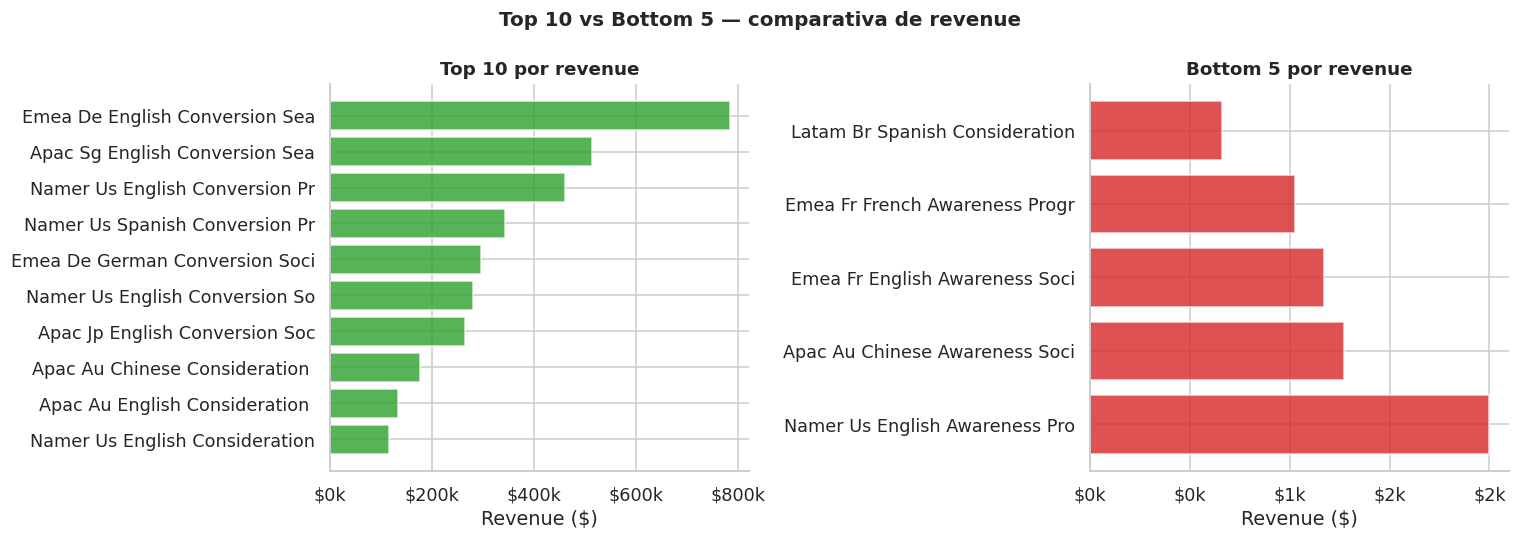


ROAS promedio Top 10  : 2.75
ROAS promedio Bottom 5: 0.03


In [19]:
# Merge para tener nombres
camp_named = campaigns_valid.merge(
    dim_campaign[["campaign_id", "campaign"]], on="campaign_id", how="left"
)
name_col = "campaign_y" if "campaign_y" in camp_named.columns else "campaign"

camp_grouped = (
    camp_named
    .groupby(name_col)
    .agg(spend=("spend","sum"), revenue=("revenue","sum"),
         clicks=("clicks","sum"), impressions=("impressions","sum"),
         purchase=("purchase","sum"))
    .assign(roas=lambda d: d.revenue / d.spend,
            ctr =lambda d: d.clicks  / d.impressions * 100)
    .reset_index()
    .rename(columns={name_col: "campaign"})
)

top10_df    = camp_grouped.nlargest(10, "revenue")
bottom5_df  = camp_grouped.nsmallest(5, "revenue")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df, title, color in [(axes[0], top10_df, "Top 10 por revenue", "#2ca02c"),
                              (axes[1], bottom5_df, "Bottom 5 por revenue", "#d62728")]:
    short = df["campaign"].str.replace("_", " ").str.title().str[:30]
    ax.barh(short, df["revenue"], color=color, alpha=0.8)
    ax.set_xlabel("Revenue ($)")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1e3:.0f}k"))
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.invert_yaxis()

plt.suptitle("Top 10 vs Bottom 5 — comparativa de revenue", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nROAS promedio Top 10  :", top10_df["roas"].mean().round(2))
print("ROAS promedio Bottom 5:", bottom5_df["roas"].mean().round(2))

### 4.7 Análisis de estacionalidad

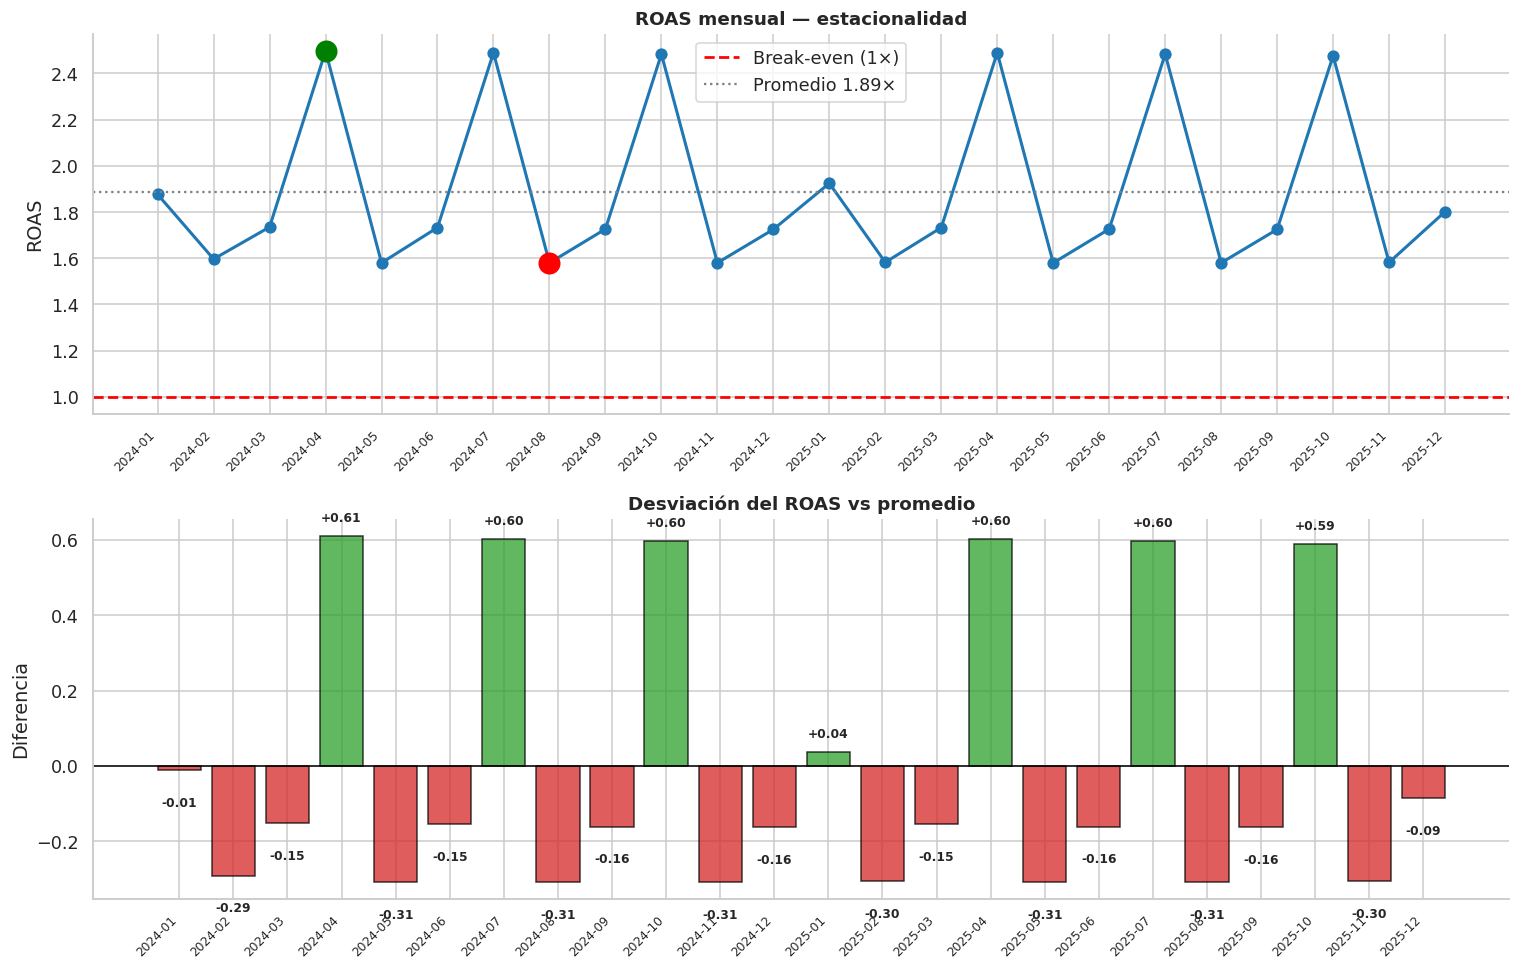

In [20]:
seas = (
    campaigns_valid
    .groupby("year_month")
    .apply(lambda x: x["revenue"].sum() / x["spend"].sum())
    .rename("roas")
    .reset_index()
)
seas["ym_str"] = seas["year_month"].astype(str)
seas["dev"]    = seas["roas"] - seas["roas"].mean()
roas_prom_seas = seas["roas"].mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Línea ROAS mensual
ax = axes[0]
ax.plot(seas["ym_str"], seas["roas"], marker="o", lw=2, ms=7, color="#1f77b4")
ax.axhline(1,             color="red",   ls="--", lw=1.8, label="Break-even (1×)")
ax.axhline(roas_prom_seas, color="gray", ls=":",  lw=1.5, label=f"Promedio {roas_prom_seas:.2f}×")
max_idx = seas["roas"].idxmax()
min_idx = seas["roas"].idxmin()
ax.scatter(seas.loc[max_idx, "ym_str"], seas.loc[max_idx, "roas"], color="green", s=180, zorder=6)
ax.scatter(seas.loc[min_idx, "ym_str"], seas.loc[min_idx, "roas"], color="red",   s=180, zorder=6)
ax.set_title("ROAS mensual — estacionalidad", fontsize=12, fontweight="bold")
ax.set_ylabel("ROAS")
ax.legend()
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)

# Desviación vs promedio
ax2 = axes[1]
colors_dev = ["#2ca02c" if d > 0 else "#d62728" for d in seas["dev"]]
bars = ax2.bar(seas["ym_str"], seas["dev"], color=colors_dev, edgecolor="black", alpha=0.75)
ax2.axhline(0, color="black", lw=1)
for bar, d in zip(bars, seas["dev"]):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + (0.03 if d > 0 else -0.07),
             f"{d:+.2f}", ha="center",
             va="bottom" if d > 0 else "top", fontsize=8, fontweight="bold")
ax2.set_title("Desviación del ROAS vs promedio", fontsize=12, fontweight="bold")
ax2.set_ylabel("Diferencia")
plt.setp(ax2.get_xticklabels(), rotation=45, ha="right", fontsize=8)

plt.tight_layout()
plt.show()

### 4.8 Placement analysis

    placement     roas        cpa
Product Pages 1.847148 238.059021
Top of Search 1.847148 238.059021


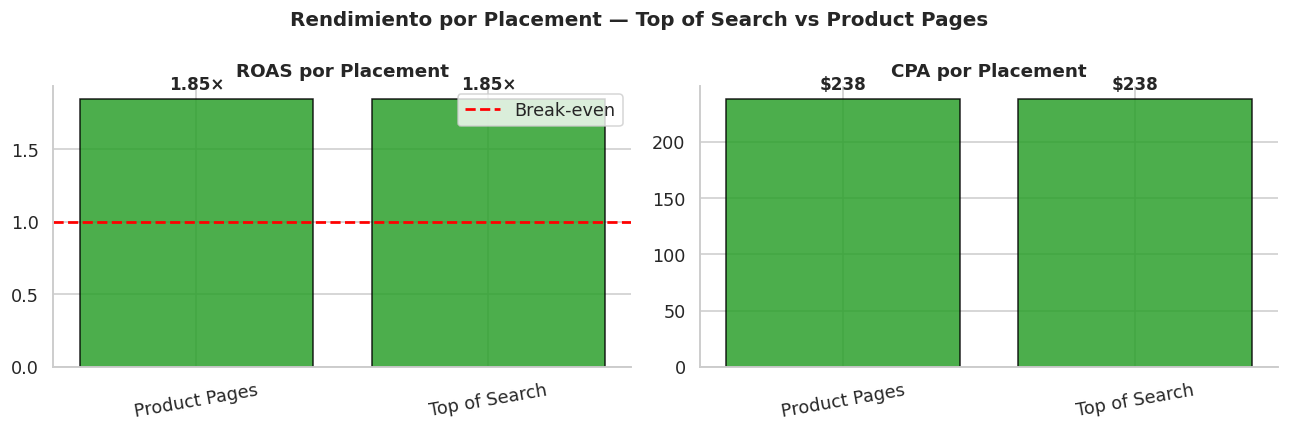

In [21]:
pl_merged = placements.merge(
    campaigns_valid[["campaign_id", "spend", "revenue", "purchase"]],
    on="campaign_id", how="left"
)

roas_pl = pl_merged.groupby("placement").apply(
    lambda x: x["revenue"].sum() / x["spend"].sum() if x["spend"].sum() > 0 else np.nan
).rename("roas").reset_index()

cpa_pl = pl_merged.groupby("placement").apply(
    lambda x: x["spend"].sum() / x["purchase"].sum() if x["purchase"].sum() > 0 else np.nan
).rename("cpa").reset_index()

pl_kpis = roas_pl.merge(cpa_pl, on="placement")
print(pl_kpis.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title, fmt in [
    (axes[0], "roas", "ROAS por Placement", "{:.2f}×"),
    (axes[1], "cpa",  "CPA por Placement",  "${:,.0f}")
]:
    colors = ["#2ca02c" if v > 1.5 else "#d62728" for v in pl_kpis[col]]
    bars = ax.bar(pl_kpis["placement"], pl_kpis[col], color=colors, edgecolor="black", alpha=0.85)
    for bar, v in zip(bars, pl_kpis[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                fmt.format(v), ha="center", va="bottom", fontsize=11, fontweight="bold")
    if col == "roas":
        ax.axhline(1, color="red", ls="--", lw=1.8, label="Break-even")
        ax.legend()
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.tick_params(axis="x", rotation=10)

plt.suptitle("Rendimiento por Placement — Top of Search vs Product Pages", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 4.9 Análisis de margen de contribución estimado

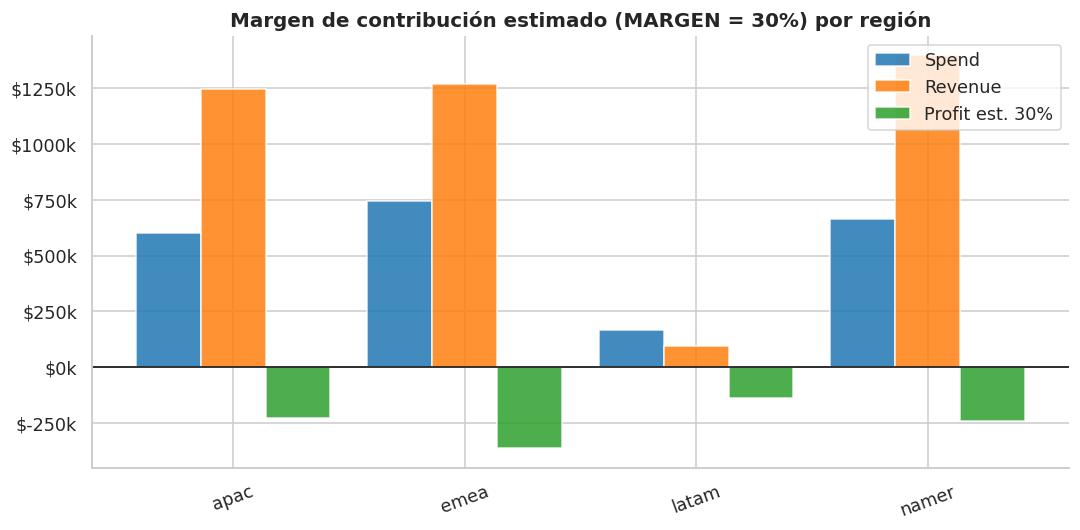


ROI estimado por región (margen 30%):
       roi_est
region        
apac    -37.9%
emea    -48.8%
latam   -83.0%
namer   -36.7%


In [22]:
MARGEN = 0.30  # supuesto: 30% de margen sobre revenue

campaigns_valid["profit_est"] = campaigns_valid["revenue"] * MARGEN - campaigns_valid["spend"]
campaigns_valid["roi_est"]    = campaigns_valid["profit_est"] / campaigns_valid["spend"]

profit_region = (
    campaigns_valid.groupby("region")[["spend", "revenue", "profit_est"]].sum()
    .assign(roi_est=lambda d: d.profit_est / d.spend * 100)
)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(profit_region))
w = 0.28
ax.bar(x - w,   profit_region["spend"],      w, label="Spend",          color="#1f77b4", alpha=0.85)
ax.bar(x,       profit_region["revenue"],    w, label="Revenue",        color="#ff7f0e", alpha=0.85)
ax.bar(x + w,   profit_region["profit_est"], w, label="Profit est. 30%",color="#2ca02c", alpha=0.85)
ax.axhline(0, color="black", lw=1)
ax.set_xticks(x)
ax.set_xticklabels(profit_region.index, rotation=20)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1e3:.0f}k"))
ax.set_title(f"Margen de contribución estimado (MARGEN = {MARGEN:.0%}) por región",
             fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

print("\nROI estimado por región (margen 30%):")
print(profit_region["roi_est"].apply(lambda v: f"{v:.1f}%").to_frame())

---
## Parte 5: Conclusiones

## Resumen y Conclusiones de Negocio

---

### Hallazgos críticos

| # | Hallazgo | Que haría yo |
|---|----------|--------------------|
| 1 | **EMEA programmatic: ROAS 0.02×** — destruye valor activamente | **Pausar o redirigir a search** |
| 2 | **LATAM social + awareness: ROAS 0.08×** | **Pausar campaña awareness en LATAM** |
| 3 | Drop del **99.6%** entre Page visits → Add to cart | **Problema de producto / landing, no de medios** |
| 4 | **NAMER social conversion: ROAS 2.41×** | **Escalar — incrementar presupuesto** |
| 5 | **EMEA search conversion: ROAS 3.19×** — mejor canal en EMEA | **Escalar dentro de EMEA** |

---

### Perspectiva Macroeconómica (Eficiencia de Canales y Regiones)

* **Las Joyas de la Corona:** El canal **Search** consolida su posición como el motor más eficiente a nivel global, destacando con un ROAS general superior a 2.8× en las regiones APAC y EMEA. A su vez, el objetivo específico de **Conversion** trepa a un promedio general de 3.16×. En el plano de **Social**, el dominio absoluto es exclusivo de NAMER con un ROAS de 2.41×.
* **El "Quemadero" de Presupuesto:** Las campañas globales con objetivo puro de **Awareness** operan con un alarmante ROAS promedio de 0.10×. Financieramente actúan como un centro de pérdida masiva y no están logrando alimentar el embudo inferior. A esto se suma que la región **LATAM opera con pérdidas sistémicas (ROAS consolidado de 0.56×)**, muy lejos de su punto de equilibrio (*break-even*), penalizada por un costo por adquisición (CPA) que desborda el margen del ticket promedio local.

---

### Regla 80/20 y Concentración del Revenue

El **top 20–30% de campañas genera el 80% del revenue**.
Las campañas de Black Friday y App Installs son outliers positivos: representan un benchmark de rendimiento histórico que debe usarse como referencia de escala para futuras planificaciones comerciales.

---

### Eficiencia de canales

- **Search** es el canal más eficiente en APAC y EMEA (ROAS > 2.8×).
- **Social** domina en NAMER (ROAS 2.41×).
- **Programmatic** solo es rentable en NAMER (ROAS 2.20×); en EMEA y LATAM destruye valor.

---

### Seasonality insight

El ROAS es relativamente estable mes a mes, con picos en **Black Friday (noviembre)** y campañas de App Installs. El negocio no tiene una estacionalidad pronunciada salvo en esas fechas específicas, lo que facilita la proyección de presupuestos fijos sin necesidad de fuertes ajustes estacionales.

---

### KPIs target recomendados para el dashboard

| KPI | Umbral OK | Alerta roja | Justificación Basada en los Datos (EDA) |
|-----|-----------|-------------|-----------------------------------------|
| **ROAS** | ≥ 1.5× | < 1.0× | Garantiza que ninguna dimensión clave opere por debajo del punto de equilibrio. |
| **CPA** | ≤ $250 | > $500 | Evita la pérdida marginal observada en los canales ineficientes de LATAM/EMEA. |
| **CTR** | ≥ 2.0% | < 1.0% | Mide la relevancia de los anuncios y el interés real de la audiencia. |
| **CVR** | ≥ 0.15% | < 0.05% | Expone de inmediato anomalías técnicas o de UX en la landing (como el drop del 99.6%). |
| **Budget utilization** | 80–100% | < 70% | Detecta campañas sub-optimizadas que no logran ejecutar la pauta asignada. |

---

### Conclusión de Diseño para Power BI

Este análisis matemático justifica técnicamente por qué el Dashboard implementará una arquitectura dinámica mediante parámetros de campos para alternar vistas (Región, Objetivo, Canal). El usuario corporativo final necesita aislar con urgencia las métricas de LATAM y las campañas de Awareness para detener fugas de presupuesto y proteger el margen neto global.